In [ ]:
# Setting personal parameters
SID4         = 5775 # last four digits of SJSU ID
SEED         = SID4        # torch.manual_seed, np.random.seed, random_state
SLICE        = SID4 % 1000   # start index of dataset subset
HP_ID        = SID4 % 6      # assigned hyperparameter arm, Table 0.1
CLS_A = SID4 % 10
CLS_B = (
    CLS_A + 1 + ((SID4 // 10) % 9)
) % 10   # two focus classes

import numpy as np
import torch
import random

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
import os
from dotenv import load_dotenv
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import html

import time
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss
)
from scipy.stats import binomtest

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading the dataset**

In [ ]:
load_dotenv()

hf_token = os.getenv("HF_TOKEN")

In [ ]:
from getpass import getpass
from huggingface_hub import whoami

hf_token = getpass("Enter your Hugging Face token: ")

print("Authenticated as:", whoami(token=hf_token)["name"])

Enter your Hugging Face token:  ········


Authenticated as: rajaleomkar14


In [ ]:
data = load_dataset("fancyzhx/yelp_polarity",
                 token=hf_token)

In [ ]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})

**Analyzing some reviews**

In [ ]:
data["train"][0]

{'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.",
 'label': 0}

In [ ]:
data["train"][86501]

{'text': 'Best country breakfast in Chandler. Eggs were perfect ham was moist. Biscuits and gravy Awesome',
 'label': 1}

In [ ]:
print(data["train"][12]["text"])

After a morning of Thrift Store hunting, a friend and I were thinking of lunch, and he suggested Emil's after he'd seen Chris Sebak do a bit on it and had tried it a time or two before, and I had not. He said they had a decent Reuben, but to be prepared to step back in time.\n\nWell, seeing as how I'm kind of addicted to late 40's and early 50's, and the whole Rat Pack scene, stepping back in time is a welcomed change in da burgh...as long as it doesn't involve 1979, which I can see all around me every day.\n\nAnd yet another shot at finding a decent Reuben in da burgh...well, that's like hunting the Holy Grail. So looking under one more bush certainly wouldn't hurt.\n\nSo off we go right at lunchtime in the middle of...where exactly were we? At first I thought we were lost, driving around a handful of very rather dismal looking blocks in what looked like a neighborhood that had been blighted by the building of a highway. And then...AHA! Here it is! And yep, there it was. This little u

In [ ]:
  data["train"][7823]

{'text': "10 years ago I came in regularly and enjoyed.  The bar lost its self and I stopped going in completely.  Earlier this year I got a coupon and decided to walk in to take a glance at the selection.  The restaurant wasn't crowded at all, but I was shocked how fresh the food looked so I settled down to enjoy excellent cooked crab legs, cray fish, shrimp. Salt/pepper octopus..  great cooks and fresh,  also ice cold beer.  The only thing that can use help with is the sushi.  They do not do any real selection but everything else out ways the sushi.  Enjoy!!",
 'label': 1}

In [ ]:
data["train"][-1]

{'text': "Ryan Rocks! I called him this morning for some sprinkler help and some potential landscaping for my backyard. He showed up to my house within an hour and answered all of my questions! When I showed him how my irrigation box was leaking, he knew right away what to do - he went a grabbed a new part out of his truck, put it on, and it was fixed! He then set up my watering timer and we talked about some landscaping and pricing. His prices seemed great and I will definitely use him in the future! To top it all off, when I asked him what I owed him for fixing my irrigation leak and his time, he said don't worry about it! I was shocked and couldn't believe his service! Thank you so much Ryan!",
 'label': 1}

**Observations**

- reviews are from different domains like medical, restaurant, service, etc
- Numbers that could have meaning like . Rating is given as "2 stars" in first review
- Long review text
- Some bold test in between review. Example review 12 . No space between the words

# 2.1 Data Preprocessing

In [ ]:
# extracting train and test datasets

train_df = data["train"].to_pandas()
test_df = data["test"].to_pandas()

In [ ]:
train_df.shape , test_df.shape

((560000, 2), (38000, 2))

In [ ]:
train_df.columns , test_df.columns

(Index(['text', 'label'], dtype='str'), Index(['text', 'label'], dtype='str'))

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
train_df.head(15)

,text,label
0,"Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff. It seems that his staff simply never answers the phone. It usually takes 2 hours of repeated calling to get an answer. Who has time for that or wants to deal with it? I have run into this problem with many other doctors and I just don't get it. You have office workers, you have patients with medical needs, why isn't anyone answering the phone? It's incomprehensible and not work the aggravation. It's with regret that I feel that I have to give Dr. Goldberg 2 stars.",0
1,"Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started at MHMG. He's been great over the years and is really all about the big picture. It is because of him, not my now former gyn Dr. Markoff, that I found out I have fibroids. He explores all options with you and is very patient and understanding. He doesn't judge and asks all the right questions. Very thorough and wants to be kept in the loop on every aspect of your medical health and your life.",1
2,"I don't know what Dr. Goldberg was like before moving to Arizona, but let me tell you, STAY AWAY from this doctor and this office. I was going to Dr. Johnson before he left and Goldberg took over when Johnson left. He is not a caring doctor. He is only interested in the co-pay and having you come in for medication refills every month. He will not give refills and could less about patients's financial situations. Trying to get your 90 days mail away pharmacy prescriptions through this guy is a joke. And to make matters even worse, his office staff is incompetent. 90% of the time when you call the office, they'll put you through to a voice mail, that NO ONE ever answers or returns your call. Both my adult children and husband have decided to leave this practice after experiencing such frustration. The entire office has an attitude like they are doing you a favor. Give me a break! Stay away from this doc and the practice. You deserve better and they will not be there when you really need them. I have never felt compelled to write a bad review about anyone until I met this pathetic excuse for a doctor who is all about the money.",0
3,"I'm writing this review to give you a heads up before you see this Doctor. The office staff and administration are very unprofessional. I left a message with multiple people regarding my bill, and no one ever called me back. I had to hound them to get an answer about my bill. \n\nSecond, and most important, make sure your insurance is going to cover Dr. Goldberg's visits and blood work. He recommended to me that I get a physical, and he knew I was a student because I told him. I got the physical done. Later, I found out my health insurance doesn't pay for preventative visits. I received an $800.00 bill for the blood work. I can't pay for my bill because I'm a student and don't have any cash flow at this current time. I can't believe the Doctor wouldn't give me a heads up to make sure my insurance would cover work that wasn't necessary and was strictly preventative. The office can't do anything to help me cover the bill. In addition, the office staff said the onus is on me to make sure my insurance covers visits. Frustrating situation!",0
4,"All the food is great here. But the best thing they have is their wings. Their wings are simply fantastic!! The \""""Wet Cajun\"""" are by the best & most popular. I also like the seasoned salt wings. Wing Night is Monday & Wednesday night, $0.75 whole wings!\n\nThe dining area is nice. Very family friendly! The bar is very nice is well. This place is truly a Yinzer's dream!! \""""Pittsburgh Dad\"""" would love this place n'at!!",1
5,"Wing sauce is like water. Pretty much a lot of butter and some hot sauce (franks red hot maybe). The whole wings are good size and crispy, but for $1 a wing the sauce could be better. The hot and

**Some bold and colored text in reviews**

In [ ]:
# Analyzing class balance
train_df["label"].value_counts()/train_df.shape[0]

label
0    0.5
1    0.5
Name: count, dtype: float64

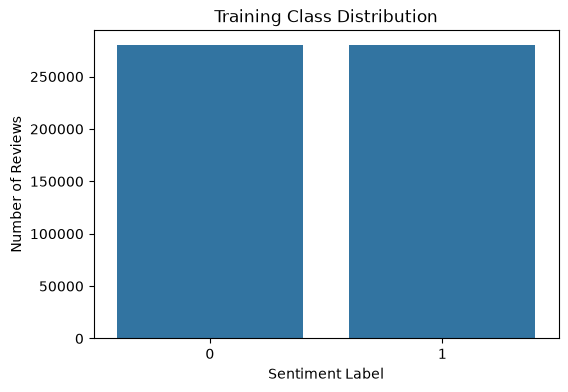

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train_df, x="label")

plt.title("Training Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Reviews")
plt.show()

**class is equally distributed**

In [ ]:
# Checking for missing values

train_df.isnull().sum()

text     0
label    0
dtype: int64

**No missing values**

In [ ]:
# checking if any reviews have empty string
print("Empty training reviews:", (train_df["text"].fillna("").str.strip() == "").sum())

Empty training reviews: 0


**Analyzing review length**

In [ ]:
# Analyzing review length

train_df["word_count"] = train_df["text"].fillna("").str.split().str.len()
train_df["char_count"] = train_df["text"].fillna("").str.len()

test_df["word_count"] = test_df["text"].fillna("").str.split().str.len()
test_df["char_count"] = test_df["text"].fillna("").str.len()

train_df[["word_count", "char_count"]].describe()

,word_count,char_count
count,560000.000000,560000.000000
mean,133.028873,726.497923
std,122.611613,669.844273
min,1.000000,1.000000
25%,51.000000,279.000000
50%,97.000000,528.000000
75%,174.000000,947.000000
max,1052.000000,5273.000000


In [ ]:
test_df[["word_count", "char_count"]].describe()

,word_count,char_count
count,38000.000000,38000.000000
mean,132.558632,723.844658
std,121.216615,662.306300
min,1.000000,4.000000
25%,51.000000,280.000000
50%,97.000000,528.000000
75%,173.000000,944.000000
max,1007.000000,5107.000000


Both train and test have roughly same distribution. Mean words are about 133 and mean characters are about 726.

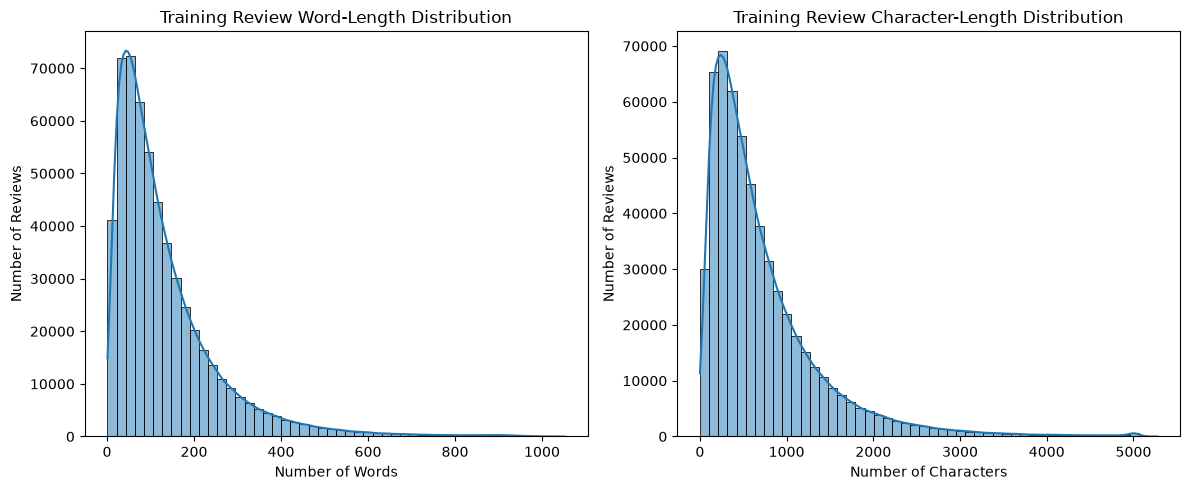

In [ ]:
# plotting review-length distribution

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_df["word_count"], bins=50, kde=True)
plt.title("Training Review Word-Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.subplot(1, 2, 2)
sns.histplot(train_df["char_count"], bins=50, kde=True)
plt.title("Training Review Character-Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

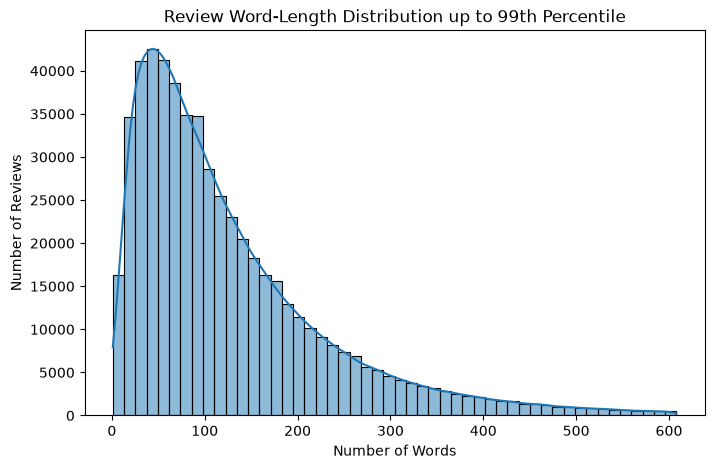

In [ ]:
word_length_limit = train_df["word_count"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    train_df[train_df["word_count"] <= word_length_limit]["word_count"],
    bins=50,
    kde=True
)

plt.title("Review Word-Length Distribution up to 99th Percentile")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

Data is skewed towards right, most reviews have an average of about 130 words. Some reviews have very long text wich could be outlier

**Checking reviews with formatting tags**

In [ ]:
html_mask = train_df["text"].fillna("").str.contains(
    r"<[^>]+>|&[a-zA-Z]+;",
    regex=True
)

print("Reviews containing HTML-like formatting:", html_mask.sum())


Reviews containing HTML-like formatting: 22


In [ ]:
# checking for HTML entities
html_entities = []

for review in train_df.loc[html_mask, "text"]:
    html_entities.extend(re.findall(r"&[#a-zA-Z0-9]+;", review))

print(Counter(html_entities))

Counter({'&amp;': 18, '&quot;': 11, '&apos;': 5, '&gt;': 3, '&S;': 1, '&found;': 1, '&lt;': 1, '&e;': 1})


These are some malformed entities notation which needs to be normalized later

**Checking reviews containing numbers**

In [ ]:
number_mask = train_df["text"].fillna("").str.contains(r"\d", regex=True)

print("Reviews containing numbers:", number_mask.sum())


Reviews containing numbers: 288902


**Checking for duplicates**

In [ ]:
train_duplicate_count = train_df["text"].duplicated().sum()
test_duplicate_count = test_df["text"].duplicated().sum()

print("Duplicate reviews in training set:", train_duplicate_count)
print("Duplicate reviews in testing set:", test_duplicate_count)

Duplicate reviews in training set: 0
Duplicate reviews in testing set: 0


No duplicates

**Checking for reviews appearing in both train and test**

In [ ]:
# checking if exact same review appears in both train and test
train_texts = set(train_df["text"].dropna())
test_texts = set(test_df["text"].dropna())

overlapping_reviews = train_texts.intersection(test_texts)

print("Reviews appearing in both train and test:", len(overlapping_reviews))

Reviews appearing in both train and test: 0


No same reviews are appearing in train and test

**Inspecting unusual formatting**

In [ ]:
def inspect_text_patterns(df, name):
    text = df["text"].fillna("").astype(str)

    print(f"\n{name}")
    print("-" * 40)

    print("Reviews with uppercase letters:",
          text.str.contains(r"[A-Z]").sum())

    print("Reviews with newline characters:",
          text.str.contains(r"[\r\n]").sum())

    print("Reviews with URLs:",
          text.str.contains(r"https?://|www\.", case=False, regex=True).sum())

    print("Reviews with Markdown bold markers:",
          text.str.contains(r"\*\*").sum())

    print("Reviews with repeated punctuation:",
          text.str.contains(r"[!?]{2,}|\.{2,}", regex=True).sum())

    print("Reviews with non-ASCII characters:",
          text.str.contains(r"[^\x00-\x7F]", regex=True).sum())

    print("Reviews with HTML entities:",
          text.str.contains(r"&[#a-zA-Z0-9]+;", regex=True).sum())


inspect_text_patterns(train_df, "Training set")
inspect_text_patterns(test_df, "Testing set")


Training set
----------------------------------------
Reviews with uppercase letters: 553719
Reviews with newline characters: 0
Reviews with URLs: 2755
Reviews with Markdown bold markers: 3291
Reviews with repeated punctuation: 193680
Reviews with non-ASCII characters: 0
Reviews with HTML entities: 27

Testing set
----------------------------------------
Reviews with uppercase letters: 37541
Reviews with newline characters: 0
Reviews with URLs: 190
Reviews with Markdown bold markers: 233
Reviews with repeated punctuation: 13133
Reviews with non-ASCII characters: 0
Reviews with HTML entities: 2


**Reviews containing only special characters**

In [ ]:
text = train_df["text"].fillna("").astype(str)

punctuation_only = text[
    text.str.strip().ne("") &
    text.str.fullmatch(r"[^A-Za-z0-9]+")
]

print("Reviews containing no letters or digits:", len(punctuation_only))

for review in punctuation_only.head(10):
    print(repr(review))

Reviews containing no letters or digits: 21
'.'
'...'
'....'
':)'
'?'
':('
':/'
': /'
': ('
'$$$$$$$'


Some emojis are present

**Checking for the presence of emojis**

In [ ]:

ascii_emoticon_pattern = re.compile(
    r"(?<!\w)(?::|;|=|8)(?:-)?(?:\)|\(|D|P|p|/|\\|\||"
    r"\*|정)|"
    r"(?<!\w)<3",
    flags=re.IGNORECASE
)

text = train_df["text"].fillna("").astype(str)

train_df["ascii_emoticons"] = text.apply(
    lambda review: ascii_emoticon_pattern.findall(review)
)

reviews_with_emoticons = train_df[
    train_df["ascii_emoticons"].str.len() > 0
]

print("Reviews containing ASCII emoticons:",
      len(reviews_with_emoticons))

print("\nEmoticon counts:")
print(
    Counter(
        emoticon.lower()
        for emoticons in train_df["ascii_emoticons"]
        for emoticon in emoticons
    )
)

Reviews containing ASCII emoticons: 25707

Emoticon counts:
Counter({':)': 12215, ':(': 3942, ';)': 2248, ':-)': 1824, '8p': 1533, '=)': 1137, ':\\': 775, ':d': 769, '8/': 681, ':/': 668, ':p': 571, ':-(': 531, ';-)': 467, '8)': 390, '=(': 287, '=\\': 267, '8\\': 233, ':-/': 167, '=p': 160, '=/': 160, '=d': 122, ';p': 84, ';(': 65, ':-d': 63, ';\\': 60, ':-p': 59, ';d': 45, ':-|': 25, ':|': 23, ';-(': 20, '8-p': 19, ';/': 17, ':*': 14, ':-\\': 14, '=-)': 12, ';-p': 10, '8(': 9, '8d': 8, '8-)': 8, ';-d': 6, '8-d': 5, '=-d': 4, ';-/': 3, '=|': 3, '=-(': 3, '8*': 3, '8-(': 2, '=*': 2, ';|': 2, '=-p': 1, '8-|': 1, ';*': 1, '8-/': 1})


There are ASCII emotions which cannot be removed. Need to normalize them later.

Preserve punctuations as they contain sentiment information

**Inspecting very short reviews**

In [ ]:
## inspecting very short reviews
word_count = train_df["text"].fillna("").str.split().str.len()
char_count = train_df["text"].fillna("").str.len()

print("Reviews with 1 word or fewer:", (word_count <= 1).sum())
print("Reviews with 2 words or fewer:", (word_count <= 2).sum())
print("Reviews with 5 words or fewer:", (word_count <= 5).sum())
print("Reviews with fewer than 10 characters:", (char_count < 10).sum())

Reviews with 1 word or fewer: 302
Reviews with 2 words or fewer: 830
Reviews with 5 words or fewer: 3861
Reviews with fewer than 10 characters: 310


In [ ]:
short_review_mask = word_count <= 2

print(
    train_df.loc[short_review_mask, "label"]
    .value_counts()
    .sort_index()
)

label
0    416
1    414
Name: count, dtype: int64


In [ ]:
short_reviews = train_df.loc[short_review_mask, ["text", "label"]]

for _, row in short_reviews.head(20).iterrows():
    print(f"Label: {row['label']} | Review: {repr(row['text'])}")

Label: 0 | Review: 'Hoofah.'
Label: 0 | Review: 'Nope!'
Label: 0 | Review: 'ewwww'
Label: 0 | Review: 'Great'
Label: 1 | Review: 'Good food'
Label: 0 | Review: 'A'
Label: 1 | Review: 'Fabulous!'
Label: 1 | Review: 'Beer cave!!'
Label: 1 | Review: 'Fantastic martinis!!'
Label: 1 | Review: 'Awesome'
Label: 1 | Review: 'Super Sundae.'
Label: 1 | Review: 'Exquisite!!'
Label: 1 | Review: 'www.bigtsreviews.com'
Label: 0 | Review: '.'
Label: 0 | Review: 'Booooo'
Label: 0 | Review: 'Horrible!!'
Label: 0 | Review: 'Very inconsistent.'
Label: 1 | Review: 'great team,'
Label: 1 | Review: 'Good buffet!'
Label: 1 | Review: 'session key'


**Single word reviews are still meaningful**

## Data Preparation

In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.corpus import stopwords

In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Keep negation words because they carry sentiment:
# "not good" must not become just "good".
negation_words = {
    "no", "nor", "not", "never", "none", "nobody", "nothing",
    "neither", "nowhere", "cannot", "can't", "won't", "isn't",
    "wasn't", "don't", "doesn't", "didn't", "shouldn't", "wouldn't",
    "couldn't", "haven't", "hasn't", "hadn't"
}

stop_words = set(stopwords.words("english")) - negation_words

# Convert common text emoticons into sentiment-bearing tokens before
# punctuation/special-character removal.
emoticon_replacements = [
    (r"(?<!\w)(?::|;|=|8)-?(?:\)|D)(?!\w)", " positiveemoticon "),
    (r"(?<!\w)(?::|;|=|8)-?(?:\(|/|\\)(?!\w)", " negativeemoticon "),
    (r"(?<!\w)<3(?!\w)", " positiveemoticon "),
]

In [ ]:
def clean_review(text):
    text = str(text)

    # Decode entities before processing apostrophes/contractions
    text = html.unescape(text)

    # Remove literal escape sequences such as "\n", "\N", "\t", and "\r"
    text = re.sub(r"\\[nrt]", " ", text, flags=re.IGNORECASE)

    # Expand contractions
    contractions = {
        r"\bwon't\b": "will not",
        r"\bcan't\b": "cannot",
        r"\bshan't\b": "shall not",
        r"\bain't\b": "is not",
        r"\b(\w+)n't\b": r"\1 not",
        r"\b(\w+)'re\b": r"\1 are",
        r"\b(\w+)'ve\b": r"\1 have",
        r"\b(\w+)'ll\b": r"\1 will",
        r"\b(\w+)'d\b": r"\1 would",
        r"\b(\w+)'m\b": r"\1 am",
        r"\b(\w+)'s\b": r"\1 is",
    }

    for pattern, replacement in contractions.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # Remove URLs because they do not describe review sentiment
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Preserve the sentiment carried by ASCII emoticons
    for pattern, replacement in emoticon_replacements:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # Lowercase before word processing
    text = text.lower()

    # Keep alphabetic words only; punctuation, digits, and special characters go away
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove stopwords but retain negation words
    tokens = [word for word in text.split() if word not in stop_words]

    # Avoid empty sequences after cleaning
    return " ".join(tokens) if tokens else "emptyreview"

In [ ]:
# applying review cleaning function on train and test
train_df["clean_text"] = train_df["text"].apply(clean_review)
test_df["clean_text"] = test_df["text"].apply(clean_review)

print("Empty placeholders in training set:",
      (train_df["clean_text"] == "emptyreview").sum())

print("\nOriginal review:")
print(train_df.loc[0, "text"])

print("\nCleaned review:")
print(train_df.loc[0, "clean_text"])

Empty placeholders in training set: 38

Original review:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.

Cleaned review:
unfortunately frustration dr goldberg patient repeat experience many doctors nyc good doctor terrible staff seems staff simply never answers phone usually takes hours repeated calling get answer time wants deal run problem many doctors not get office workers patients medical needs 

**Lemmatization was not applied. Since the embeddings are learned from scratch, preserving original word forms can retain sentiment-relevant distinctions such as tense and intensity. The model vocabulary will be constructed from the cleaned training text only**

## Train-Validation, test split

In [ ]:
# !pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split

taking validation from train

In [ ]:
train_split_df, val_df = train_test_split(
    train_df[["clean_text", "label"]],
    test_size=0.10,          # 56,000 validation reviews
    stratify=train_df["label"],
    random_state=SEED
)

In [ ]:
# Reset indices to avoid carrying original dataset indices forward
train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [ ]:
print("Training split:", train_split_df.shape)
print("Validation split:", val_df.shape)
print("Official test set:", test_df[["clean_text", "label"]].shape)

print("\nClass proportions")
print("Training:\n", train_split_df["label"].value_counts(normalize=True).sort_index())
print("Validation:\n", val_df["label"].value_counts(normalize=True).sort_index())
print("Test:\n", test_df["label"].value_counts(normalize=True).sort_index())

Training split: (504000, 2)
Validation split: (56000, 2)
Official test set: (38000, 2)

Class proportions
Training:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Validation:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64


all classes are balanced

### Tokenization

Cleaned training-review token-length percentiles:
0.50     50
0.75     89
0.90    144
0.95    190
0.98    255
0.99    311
Name: clean_text, dtype: int64


,max_length,reviews_fully_kept (%),reviews_truncated (%)
0,128,87.25,12.75
1,160,92.31,7.69
2,192,95.20,4.80
3,224,96.96,3.04
4,256,98.04,1.96
5,320,99.11,0.89
6,384,99.56,0.44
7,512,99.99,0.01


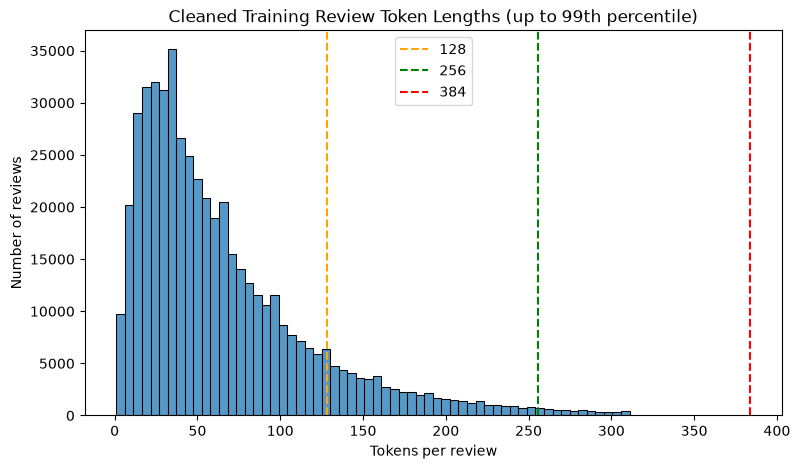

In [ ]:
train_lengths = train_split_df["clean_text"].str.split().str.len()

percentiles = train_lengths.quantile(
    [0.50, 0.75, 0.90, 0.95, 0.98, 0.99]
).round().astype(int)

print("Cleaned training-review token-length percentiles:")
print(percentiles)

candidate_lengths = [128, 160, 192, 224, 256, 320, 384, 512]

coverage = pd.DataFrame({
    "max_length": candidate_lengths,
    "reviews_fully_kept (%)": [
        round((train_lengths <= length).mean() * 100, 2)
        for length in candidate_lengths
    ],
    "reviews_truncated (%)": [
        round((train_lengths > length).mean() * 100, 2)
        for length in candidate_lengths
    ]
})

display(coverage)

plt.figure(figsize=(9, 5))
sns.histplot(train_lengths[train_lengths <= train_lengths.quantile(0.99)],
             bins=60)
plt.axvline(128, color="orange", linestyle="--", label="128")
plt.axvline(256, color="green", linestyle="--", label="256")
plt.axvline(384, color="red", linestyle="--", label="384")
plt.title("Cleaned Training Review Token Lengths (up to 99th percentile)")
plt.xlabel("Tokens per review")
plt.ylabel("Number of reviews")
plt.legend()
plt.show()

**Sequence-length decision:The 95th-percentile cleaned review length is 190 tokens. So selected MAX_LEN = 192, retaining 95.20% of reviews without truncation while reducing padding, memory use, and training time.**

In [ ]:

MAX_VOCAB_SIZE = 30_000
MIN_FREQ = 2

# The vocabulary is learned only from the training split.
# This prevents information from validation or test reviews leaking into training.
word_counts = Counter()

for review in train_split_df["clean_text"]:
    word_counts.update(review.split())

# Keep words appearing at least twice, ranked by frequency.
eligible_words = [
    word for word, count in word_counts.items()
    if count >= MIN_FREQ
]

eligible_words = sorted(
    eligible_words,
    key=lambda word: (-word_counts[word], word)
)

# Reserve index 0 for padding and index 1 for unknown words.
vocab_words = eligible_words[:MAX_VOCAB_SIZE - 2]

word_to_idx = {"<pad>": 0, "<unk>": 1}
word_to_idx.update(
    {word: idx for idx, word in enumerate(vocab_words, start=2)}
)

idx_to_word = {idx: word for word, idx in word_to_idx.items()}

print(f"Unique tokens in training split: {len(word_counts):,}")
print(f"Tokens occurring at least {MIN_FREQ} times: {len(eligible_words):,}")
print(f"Final vocabulary size: {len(word_to_idx):,}")
print("\nSpecial-token IDs:", {"<pad>": word_to_idx["<pad>"], "<unk>": word_to_idx["<unk>"]})
print("\n15 most common tokens:")
print(word_counts.most_common(15))

Unique tokens in training split: 181,646
Tokens occurring at least 2 times: 97,536
Final vocabulary size: 30,000

Special-token IDs: {'<pad>': 0, '<unk>': 1}

15 most common tokens:
[('not', 902799), ('food', 302017), ('place', 290947), ('good', 273097), ('would', 253710), ('like', 237530), ('one', 216787), ('get', 214303), ('service', 195229), ('time', 195136), ('great', 192475), ('back', 176552), ('no', 173850), ('go', 171807), ('really', 153538)]


### converting tokenized reviews to integer sequences

In [ ]:
from torch.utils.data import Dataset
import torch

In [ ]:

MAX_LEN = 192

class YelpReviewDataset(Dataset):
    def __init__(self, dataframe, word_to_idx, max_len):
        self.texts = dataframe["clean_text"].tolist()
        self.labels = dataframe["label"].to_numpy()
        self.word_to_idx = word_to_idx
        self.max_len = max_len
        self.pad_idx = word_to_idx["<pad>"]
        self.unk_idx = word_to_idx["<unk>"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        tokens = self.texts[index].split()[:self.max_len]

        token_ids = [
            self.word_to_idx.get(token, self.unk_idx)
            for token in tokens
        ]

        length = len(token_ids)

        # Right-pad every review to the fixed MAX_LEN.
        token_ids += [self.pad_idx] * (self.max_len - length)

        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.long),
            torch.tensor(length, dtype=torch.long)
        )


train_dataset = YelpReviewDataset(train_split_df, word_to_idx, MAX_LEN)
val_dataset = YelpReviewDataset(val_df, word_to_idx, MAX_LEN)
test_dataset = YelpReviewDataset(
    test_df[["clean_text", "label"]], word_to_idx, MAX_LEN
)

# Sanity check one encoded example
sample_ids, sample_label, sample_length = train_dataset[0]

print("Encoded sequence shape:", sample_ids.shape)
print("Label:", sample_label.item())
print("Actual token length (after truncation):", sample_length.item())
print("First 20 token IDs:", sample_ids[:20].tolist())

print("\nDecoded non-padding tokens:")
print([
    idx_to_word[token_id]
    for token_id in sample_ids[:sample_length].tolist()
])

Encoded sequence shape: torch.Size([192])
Label: 1
Actual token length (after truncation): 36
First 20 token IDs: [311, 14042, 228, 2955, 1100, 1371, 2, 6177, 2494, 1679, 3928, 9, 118, 153, 169, 39, 312, 2, 1279, 329]

Decoded non-padding tokens:
['shop', 'builds', 'high', 'performance', 'sports', 'cars', 'not', 'alignment', 'rack', 'joe', 'tony', 'get', 'work', 'let', 'put', 'way', 'reason', 'not', 'satisfied', 'keep', 'working', 'solution', 'since', 'main', 'focus', 'alignments', 'cannot', 'afford', 'dissatisfied', 'customer', 'thanks', 'guys', 'keeping', 'customers', 'straight', 'narrow']


### Data Loaders

In [ ]:
from torch.utils.data import DataLoader

In [ ]:

BATCH_SIZE = 256
PIN_MEMORY = torch.cuda.is_available()
NUM_WORKERS = 0

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


In [ ]:
# One batch sanity check
batch_inputs, batch_labels, batch_lengths = next(iter(train_loader))

print("Input batch shape:", batch_inputs.shape)
print("Label batch shape:", batch_labels.shape)
print("Length batch shape:", batch_lengths.shape)

print("\nInput ID range:",
      batch_inputs.min().item(), "to", batch_inputs.max().item())

print("Label values:", torch.unique(batch_labels).tolist())
print("Batch length range:",
      batch_lengths.min().item(), "to", batch_lengths.max().item())

Input batch shape: torch.Size([256, 192])
Label batch shape: torch.Size([256])
Length batch shape: torch.Size([256])

Input ID range: 0 to 29951
Label values: [0, 1]
Batch length range: 1 to 192


## Model Training

In [ ]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, pad_idx, dropout=0.30):
        super().__init__()

        # Learned from scratch during training
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 2)
        )

    def forward(self, input_ids, lengths):
        # input_ids shape: [batch_size, MAX_LEN]
        embedded = self.embedding(input_ids)
        embedded = self.embedding_dropout(embedded)

        # Ignores right-padding during recurrent computation
        packed_embeddings = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden_states, _) = self.bilstm(packed_embeddings)

        # hidden_states shape: [2, batch_size, hidden_dim]
        # -2 is the final forward state; -1 is the final backward state.
        forward_final = hidden_states[-2]
        backward_final = hidden_states[-1]

        review_representation = torch.cat(
            (forward_final, backward_final),
            dim=1
        )

        return self.classifier(review_representation)


baseline_model = BiLSTMClassifier(
    vocab_size=len(word_to_idx),
    embedding_dim=128,
    hidden_dim=128,
    pad_idx=word_to_idx["<pad>"],
    dropout=0.30
).to(device)

baseline_parameter_count = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
    if parameter.requires_grad
)

print(baseline_model)
print(f"\nTrainable parameters: {baseline_parameter_count:,}")

BiLSTMClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (bilstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=2, bias=True)
  )
)

Trainable parameters: 4,104,706


In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs,
    patience,
    checkpoint_path
):
    history = []

    best_val_macro_f1 = -float("inf")
    best_epoch = 0
    best_state_dict = None
    epochs_without_improvement = 0

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    total_training_start = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        model.train()

        if device.type == "cuda":
            torch.cuda.synchronize(device)

        epoch_start = time.perf_counter()
        total_train_loss = 0.0
        total_train_examples = 0

        # Track training predictions and labels
        all_train_labels = []
        all_train_predictions = []

        for input_ids, labels, lengths in train_loader:
            input_ids = input_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            batch_size = labels.size(0)
            total_train_loss += loss.item() * batch_size
            total_train_examples += batch_size

            # Store predictions for training accuracy
            predictions = torch.argmax(logits, dim=1)
            all_train_labels.extend(labels.detach().cpu().numpy())
            all_train_predictions.extend(predictions.detach().cpu().numpy())

        if device.type == "cuda":
            torch.cuda.synchronize(device)

        epoch_time = time.perf_counter() - epoch_start

        train_loss = total_train_loss / total_train_examples

        # Calculate training accuracy
        train_accuracy = accuracy_score(
            all_train_labels,
            all_train_predictions
        )

        examples_per_second = total_train_examples / epoch_time

        validation_results = validate_model(
            model, val_loader, criterion, device
        )

        scheduler.step(validation_results["macro_f1"])

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": validation_results["loss"],
            "val_accuracy": validation_results["accuracy"],
            "val_macro_f1": validation_results["macro_f1"],
            "training_seconds": epoch_time,
            "examples_per_second": examples_per_second,
            "learning_rate": current_lr
        })

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"train accuracy: {train_accuracy:.4f} | "
            f"val loss: {validation_results['loss']:.4f} | "
            f"val accuracy: {validation_results['accuracy']:.4f} | "
            f"val macro-F1: {validation_results['macro_f1']:.4f} | "
            f"speed: {examples_per_second:.1f} examples/sec"
        )

        if validation_results["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = validation_results["macro_f1"]
            best_epoch = epoch
            epochs_without_improvement = 0

            # CPU copy ensures later epochs cannot overwrite the best weights.
            best_state_dict = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping after epoch {epoch}.")
                break

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    total_training_seconds = time.perf_counter() - total_training_start

    # Restore and save the best validation-Macro-F1 checkpoint.
    model.load_state_dict(best_state_dict)

    peak_memory_mb = (
        torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        if device.type == "cuda" else 0.0
    )

    torch.save({
        "model_state_dict": model.state_dict(),
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro_f1,
        "max_len": MAX_LEN,
        "vocab_size": len(word_to_idx),
        "model_name": "baseline_bilstm"
    }, checkpoint_path)

    run_summary = {
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro_f1,
        "total_training_seconds": total_training_seconds,
        "peak_memory_mb": peak_memory_mb
    }

    return model, pd.DataFrame(history), run_summary


In [ ]:
baseline_model, baseline_history, baseline_run_summary = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path="baseline_bilstm_best.pt"
)

display(baseline_history)
print(baseline_run_summary)

Epoch 1/5 | train loss: 0.1538 | train accuracy: 0.9397 | val loss: 0.1764 | val accuracy: 0.9411 | val macro-F1: 0.9411 | speed: 6217.2 examples/sec
Epoch 2/5 | train loss: 0.1387 | train accuracy: 0.9463 | val loss: 0.1630 | val accuracy: 0.9435 | val macro-F1: 0.9435 | speed: 6288.1 examples/sec
Epoch 3/5 | train loss: 0.1270 | train accuracy: 0.9510 | val loss: 0.1626 | val accuracy: 0.9421 | val macro-F1: 0.9421 | speed: 6204.0 examples/sec
Epoch 4/5 | train loss: 0.1177 | train accuracy: 0.9551 | val loss: 0.1606 | val accuracy: 0.9486 | val macro-F1: 0.9486 | speed: 6285.2 examples/sec
Epoch 5/5 | train loss: 0.1098 | train accuracy: 0.9579 | val loss: 0.1515 | val accuracy: 0.9501 | val macro-F1: 0.9501 | speed: 6201.7 examples/sec


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,training_seconds,examples_per_second,learning_rate
0,1,0.153784,0.939746,0.176424,0.941071,0.941068,81.065448,6217.198752,0.001
1,2,0.138686,0.946252,0.163021,0.943536,0.943531,80.150991,6288.131843,0.001
2,3,0.127017,0.951044,0.162566,0.942107,0.942092,81.237636,6204.021010,0.001
3,4,0.117709,0.955091,0.160635,0.948554,0.948553,80.187813,6285.244348,0.001
4,5,0.109827,0.957863,0.151543,0.950071,0.950071,81.267641,6201.730426,0.001


{'best_epoch': 5, 'best_val_macro_f1': 0.9500708043927983, 'total_training_seconds': 425.4416453909944, 'peak_memory_mb': 363.50244140625}


# Model Evaluation

In [ ]:

@torch.inference_mode()
def collect_predictions(model, data_loader, device):
    """Return true labels, predicted labels, and positive-class probabilities."""
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for input_ids, labels, lengths in data_loader:
        input_ids = input_ids.to(device, non_blocking=True)

        logits = model(input_ids, lengths)
        probabilities = torch.softmax(logits, dim=1)[:, 1]
        predictions = torch.argmax(logits, dim=1)

        all_labels.append(labels.cpu())
        all_predictions.append(predictions.cpu())
        all_probabilities.append(probabilities.cpu())

    return (
        torch.cat(all_labels).numpy(),
        torch.cat(all_predictions).numpy(),
        torch.cat(all_probabilities).numpy()
    )


def expected_calibration_error(y_true, positive_probabilities, n_bins=15):
    """
    ECE using the model's predicted-class confidence.
    Lower ECE indicates better probability calibration.
    """
    predictions = (positive_probabilities >= 0.5).astype(int)
    confidences = np.maximum(positive_probabilities, 1 - positive_probabilities)
    correct = (predictions == y_true).astype(float)

    bin_ids = np.minimum((confidences * n_bins).astype(int), n_bins - 1)

    ece = 0.0
    for bin_index in range(n_bins):
        mask = bin_ids == bin_index

        if mask.any():
            bin_accuracy = correct[mask].mean()
            bin_confidence = confidences[mask].mean()
            ece += mask.mean() * abs(bin_accuracy - bin_confidence)

    return ece


def bootstrap_confidence_intervals(y_true, predictions, n_bootstraps=1000, seed=SEED):
    """95% percentile bootstrap CIs for accuracy, macro-F1, and MCC."""
    rng = np.random.default_rng(seed)
    n_samples = len(y_true)

    accuracy_scores = []
    macro_f1_scores = []
    mcc_scores = []

    for _ in range(n_bootstraps):
        indices = rng.integers(0, n_samples, size=n_samples)

        boot_y_true = y_true[indices]
        boot_predictions = predictions[indices]

        accuracy_scores.append(accuracy_score(boot_y_true, boot_predictions))
        macro_f1_scores.append(
            f1_score(boot_y_true, boot_predictions, average="macro", zero_division=0)
        )
        mcc_scores.append(matthews_corrcoef(boot_y_true, boot_predictions))

    def ci(values):
        return (
            float(np.percentile(values, 2.5)),
            float(np.percentile(values, 97.5))
        )

    return {
        "accuracy_95%_CI": ci(accuracy_scores),
        "macro_f1_95%_CI": ci(macro_f1_scores),
        "mcc_95%_CI": ci(mcc_scores)
    }


def slice_metrics(y_true, predictions, raw_lengths):
    """
    Robustness metrics by original cleaned-review length.
    Pass raw lengths from val_df/test_df, not truncated dataset lengths.
    """
    raw_lengths = np.asarray(raw_lengths)

    slices = {
        "short_1_to_32": (raw_lengths <= 32),
        "medium_33_to_96": ((raw_lengths >= 33) & (raw_lengths <= 96)),
        "long_97_to_192": ((raw_lengths >= 97) & (raw_lengths <= 192)),
        "truncated_over_192": (raw_lengths > 192)
    }

    results = []

    for slice_name, mask in slices.items():
        if mask.sum() == 0:
            continue

        slice_y_true = y_true[mask]
        slice_predictions = predictions[mask]

        results.append({
            "slice": slice_name,
            "examples": int(mask.sum()),
            "macro_f1": f1_score(
                slice_y_true, slice_predictions,
                average="macro", zero_division=0
            ),
            "error_rate": 1 - accuracy_score(slice_y_true, slice_predictions)
        })

    return pd.DataFrame(results)


def evaluate_model(
    model,
    data_loader,
    device,
    raw_lengths,
    parameter_count,
    n_bootstraps=1000
):
    """
    Computes all per-model predictive metrics required by the lab.
    raw_lengths must match data_loader order; use shuffle=False for evaluation.
    """
    y_true, predictions, positive_probabilities = collect_predictions(
        model, data_loader, device
    )

    metrics = {
        "accuracy": accuracy_score(y_true, predictions),

        "precision_macro": precision_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, predictions, average="macro", zero_division=0
        ),

        "precision_micro": precision_score(
            y_true, predictions, average="micro", zero_division=0
        ),
        "recall_micro": recall_score(
            y_true, predictions, average="micro", zero_division=0
        ),
        "f1_micro": f1_score(
            y_true, predictions, average="micro", zero_division=0
        ),

        "precision_weighted": precision_score(
            y_true, predictions, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, predictions, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, predictions, average="weighted", zero_division=0
        ),

        "roc_auc": roc_auc_score(y_true, positive_probabilities),
        "pr_auc": average_precision_score(y_true, positive_probabilities),
        "mcc": matthews_corrcoef(y_true, predictions),
        "brier_score": brier_score_loss(y_true, positive_probabilities),
        "ece": expected_calibration_error(y_true, positive_probabilities),
        "parameter_count": parameter_count
    }

    confidence_intervals = bootstrap_confidence_intervals(
        y_true, predictions, n_bootstraps=n_bootstraps
    )

    return {
        "metrics": metrics,
        "confidence_intervals": confidence_intervals,
        "confusion_matrix": confusion_matrix(y_true, predictions),
        "slice_metrics": slice_metrics(y_true, predictions, raw_lengths),
        "y_true": y_true,
        "predictions": predictions,
        "positive_probabilities": positive_probabilities
    }


def exact_mcnemar_test(y_true, baseline_predictions, experimental_predictions):
    """Run after both models have predictions on the same test set."""
    baseline_correct = baseline_predictions == y_true
    experimental_correct = experimental_predictions == y_true

    baseline_only_correct = int(
        np.sum(baseline_correct & ~experimental_correct)
    )
    experimental_only_correct = int(
        np.sum(~baseline_correct & experimental_correct)
    )

    discordant_total = baseline_only_correct + experimental_only_correct

    p_value = (
        binomtest(
            min(baseline_only_correct, experimental_only_correct),
            n=discordant_total,
            p=0.5,
            alternative="two-sided"
        ).pvalue
        if discordant_total > 0 else 1.0
    )

    return {
        "baseline_only_correct": baseline_only_correct,
        "experimental_only_correct": experimental_only_correct,
        "p_value": p_value
    }

In [ ]:
test_raw_lengths = test_df["clean_text"].str.split().str.len().to_numpy()

baseline_results = evaluate_model(
    model=baseline_model,
    data_loader=test_loader,
    device=device,
    raw_lengths=test_raw_lengths,
    parameter_count=baseline_parameter_count
)

display(pd.Series(baseline_results["metrics"]))
print(baseline_results["confidence_intervals"])
print(baseline_results["confusion_matrix"])
display(baseline_results["slice_metrics"])

accuracy              9.514474e-01
precision_macro       9.514560e-01
recall_macro          9.514474e-01
f1_macro              9.514471e-01
precision_micro       9.514474e-01
recall_micro          9.514474e-01
f1_micro              9.514474e-01
precision_weighted    9.514560e-01
recall_weighted       9.514474e-01
f1_weighted           9.514471e-01
roc_auc               9.890004e-01
pr_auc                9.891941e-01
mcc                   9.029034e-01
brier_score           3.843900e-02
ece                   2.206633e-02
parameter_count       4.104706e+06
dtype: float64

{'accuracy_95%_CI': (0.9492105263157895, 0.9535789473684211), 'macro_f1_95%_CI': (0.9492105026759983, 0.9535745455486512), 'mcc_95%_CI': (0.8984269599855507, 0.9071583941935383)}
[[18119   881]
 [  964 18036]]


,slice,examples,macro_f1,error_rate
0,short_1_to_32,12071,0.950456,0.048132
1,medium_33_to_96,17650,0.956128,0.043853
2,long_97_to_192,6492,0.945913,0.052372
3,truncated_over_192,1787,0.905435,0.083940
